# Capítulo 8: Ataques Adversariales contra Modelos de IA *(Versión Simulada)*

## 8.1. Amenazas a los modelos de IA

| Tipo | Descripción |
| :--- | :--- |
| **Evasión** | Perturbaciones mínimas para que malware se clasifique como benigno. |
| **Envenenamiento** | Inyección de muestras maliciosas en entrenamiento. |
| **Inversión** | Reconstrucción de datos desde el modelo. |
| **Extracción** | Réplica del modelo mediante consultas masivas. |

Este notebook demuestra con datos **simulados** cómo un atacante puede degradar la precisión del clasificador de malware añadiendo ruido, y cómo el **entrenamiento adversarial** mitiga este efecto.

---
## 8.2. Defensa: entrenamiento adversarial

In [1]:
# Listing 8.1: Generación de ejemplos adversariales y defensa

import numpy as np
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

def generar_ejemplos_adversariales(X: np.ndarray,
                                   ruido_std: float = 0.05,
                                   seed: int = 42) -> np.ndarray:
    """
    Genera ejemplos adversariales añadiendo ruido gaussiano.
    En producción se usaría FGSM, PGD, etc.
    """
    rng = np.random.default_rng(seed)
    ruido = rng.normal(0, ruido_std, X.shape)
    return np.clip(X + ruido, 0, 1)  # mantener rango normalizado


# 1. Datos simulados de malware
df = pd.read_csv('data/file_features.csv').dropna()
X_raw, y = df.drop('label', axis=1).values, df['label'].values

# Normalizar a [0,1] para que el ruido adversarial funcione correctamente
scaler = MinMaxScaler()
X = scaler.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = RandomForestClassifier(n_estimators=200, random_state=42)
modelo.fit(X_train, y_train)

print(f"[OK] Modelo base entrenado con {len(X_train)} muestras simuladas.")

[OK] Modelo base entrenado con 800 muestras simuladas.


In [2]:
# 2. Ataque: evaluar impacto del ruido adversarial
X_test_adv = generar_ejemplos_adversariales(X_test, ruido_std=0.1)
acc_normal = accuracy_score(y_test, modelo.predict(X_test))
acc_adversa = accuracy_score(y_test, modelo.predict(X_test_adv))

print(f"Precisión normal:       {acc_normal:.4f}")
print(f"Precisión bajo ataque:  {acc_adversa:.4f}")
print(f"Degradación:            {(acc_normal - acc_adversa)*100:.2f}%")

Precisión normal:       1.0000
Precisión bajo ataque:  0.9750
Degradación:            2.50%


In [3]:
# 3. Defensa: reentrenamiento con ejemplos adversariales
X_train_robusto = np.vstack([X_train,
                              generar_ejemplos_adversariales(X_train, ruido_std=0.05)])
y_train_robusto = np.concatenate([y_train, y_train])

modelo_robusto = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_robusto.fit(X_train_robusto, y_train_robusto)

acc_robusto_normal = accuracy_score(y_test, modelo_robusto.predict(X_test))
acc_robusto_adv    = accuracy_score(y_test, modelo_robusto.predict(X_test_adv))

print(f"Modelo robusto (normal):      {acc_robusto_normal:.4f}")
print(f"Modelo robusto (bajo ataque): {acc_robusto_adv:.4f}")

Modelo robusto (normal):      1.0000
Modelo robusto (bajo ataque): 1.0000


### 8.2.1. Comparación de resultados

Escenario                             Accuracy
Modelo base (normal)                    1.0000
Modelo base (bajo ataque)               0.9750
Modelo robusto (normal)                 1.0000
Modelo robusto (bajo ataque)            1.0000


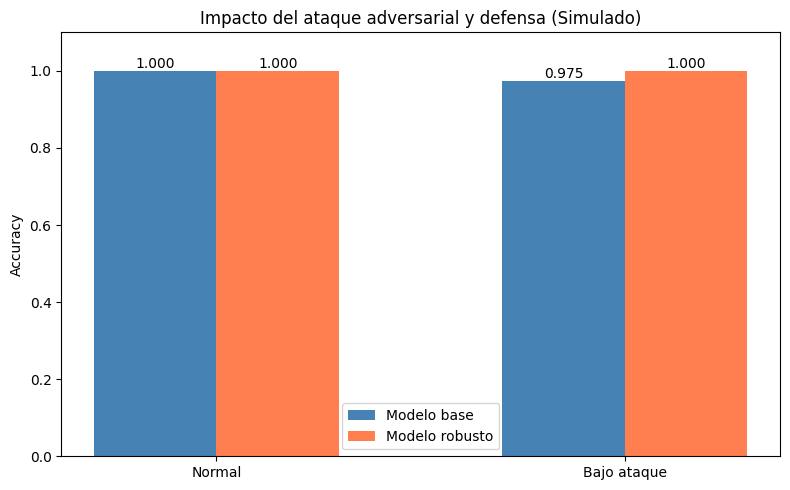

In [4]:
import matplotlib.pyplot as plt

print("=" * 55)
print(f"{'Escenario':<35} {'Accuracy':>10}")
print("=" * 55)
print(f"{'Modelo base (normal)':<35} {acc_normal:>10.4f}")
print(f"{'Modelo base (bajo ataque)':<35} {acc_adversa:>10.4f}")
print(f"{'Modelo robusto (normal)':<35} {acc_robusto_normal:>10.4f}")
print(f"{'Modelo robusto (bajo ataque)':<35} {acc_robusto_adv:>10.4f}")
print("=" * 55)

labels = ['Normal', 'Bajo ataque']
base_scores   = [acc_normal, acc_adversa]
robust_scores = [acc_robusto_normal, acc_robusto_adv]
x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, base_scores, width, label='Modelo base', color='steelblue')
bars2 = ax.bar(x + width/2, robust_scores, width, label='Modelo robusto', color='coral')
ax.set_ylabel('Accuracy')
ax.set_title('Impacto del ataque adversarial y defensa (Simulado)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('data/adversarial_comparison.png', dpi=150)
plt.show()

### 8.2.2. Análisis de sensibilidad al ruido

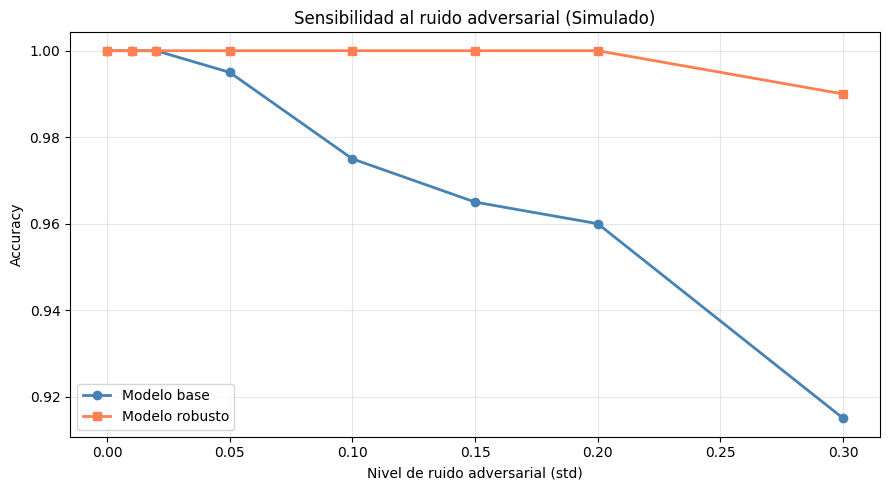

In [5]:
niveles_ruido = [0.0, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3]
acc_base_list, acc_robusto_list = [], []

for ruido in niveles_ruido:
    X_adv = X_test.copy() if ruido == 0.0 else generar_ejemplos_adversariales(X_test, ruido_std=ruido)
    acc_base_list.append(accuracy_score(y_test, modelo.predict(X_adv)))
    acc_robusto_list.append(accuracy_score(y_test, modelo_robusto.predict(X_adv)))

plt.figure(figsize=(9, 5))
plt.plot(niveles_ruido, acc_base_list, 'o-', color='steelblue', label='Modelo base', linewidth=2)
plt.plot(niveles_ruido, acc_robusto_list, 's-', color='coral', label='Modelo robusto', linewidth=2)
plt.xlabel('Nivel de ruido adversarial (std)')
plt.ylabel('Accuracy')
plt.title('Sensibilidad al ruido adversarial (Simulado)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/adversarial_sensitivity.png', dpi=150)
plt.show()

---
## 8.3. Guardado de artefactos

In [6]:
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(modelo_robusto, 'models/rf_malware_robust.pkl')
joblib.dump(scaler, 'models/scaler_malware.pkl')
print("[OK] models/rf_malware_robust.pkl")
print("[OK] models/scaler_malware.pkl")

[OK] models/rf_malware_robust.pkl
[OK] models/scaler_malware.pkl
